<a href="https://colab.research.google.com/github/sita-aghasoy33/EvoAcademyProjects/blob/main/Data_Wrangling_and_Viz_new_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Data from Excel

In [2]:
# import Bank Churn Messy data
pd.read_excel("/content/Bank_Churn_Messy.xlsx", sheet_name = "Customer_Info").head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88
1,15647311,Hill,608,Spain,Female,41.0,1,€112542.58
2,15619304,Onio,502,French,Female,42.0,8,€113931.57
3,15701354,Boni,699,FRA,Female,39.0,1,€93826.63
4,15737888,Mitchell,850,Spain,Female,43.0,2,€79084.1


In [3]:
pd.read_excel("/content/Bank_Churn_Messy.xlsx", sheet_name = "Account_Info").head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


### Reading data from Excel and creating DataFrame

In [4]:
cust_df = pd.read_excel("/content/Bank_Churn_Messy.xlsx", sheet_name = "Customer_Info")
accnt_df = pd.read_excel("/content/Bank_Churn_Messy.xlsx", sheet_name = "Account_Info")

In [5]:
accnt_df.head()

,CustomerId,Balance,NumOfProducts,HasCrCard,Tenure,IsActiveMember,Exited
0,15634602,€0.0,1,Yes,2,Yes,1
1,15634602,€0.0,1,Yes,2,Yes,1
2,15647311,€83807.86,1,Yes,1,Yes,0
3,15619304,€159660.8,3,No,8,No,1
4,15701354,€0.0,2,No,1,No,0


### Data Wrangling

In [6]:
def cust_wrangle(path):
  # Read excel sheet "Customer_Info"
  df = pd.read_excel(path, sheet_name = "Customer_Info")

  # Clean Expected Salary column
  df['EstimatedSalary [in Euros]'] = \
           (df['EstimatedSalary']
                .str.replace('€', '')
                .astype('float'))

  # Drop duplicated rows
  df.drop_duplicates(inplace=True)

  # Age binning
  bins = [0, 18, 30, 45, 60, 100]
  labels = ['0-18', '19-30', '31-45', '46-60', '61+']

  df['Age_Bins'] = pd.cut(df['Age'],
                                   bins=bins,
                                   labels=labels,
                                   right=False)

  # Replace different namings for 'France' in 'Geography' column
  df['Geography'].replace({'FRA':'France', 'French':'France'},
                                   inplace = True)


  # Convert Customer Id to object
  df['CustomerId'] = df['CustomerId'].astype('object')

  # drop columns with high cardinality
  df.drop(columns=['EstimatedSalary', 'Surname'], inplace=True)


  return df

In [9]:
clean_cust_df = cust_wrangle(path="/content/Bank_Churn_Messy.xlsx")

/tmp/ipykernel_571/3517709872.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Geography'].replace({'FRA':'France', 'French':'France'},


In [7]:
def accnt_wrangle(path):
  # Read excel sheet "Customer_Info"
  df = pd.read_excel(path, sheet_name = "Account_Info")
  return df

### Analyse and Process **'cust_df'** table

In [ ]:
cust_df = cust_wrangle("/content/Bank_Churn_Messy.xlsx")

/tmp/ipython-input-3517709872.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Geography'].replace({'FRA':'France', 'French':'France'},


In [ ]:
cust_df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary [in Euros],Age_Bins
0,15634602,619,France,Female,42.0,2,101348.88,31-45
1,15647311,608,Spain,Female,41.0,1,112542.58,31-45
2,15619304,502,France,Female,42.0,8,113931.57,31-45
3,15701354,699,France,Female,39.0,1,93826.63,31-45
4,15737888,850,Spain,Female,43.0,2,79084.10,31-45


In [ ]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   CustomerId                  10000 non-null  object  
 1   CreditScore                 10000 non-null  int64   
 2   Geography                   10000 non-null  object  
 3   Gender                      10000 non-null  object  
 4   Age                         9997 non-null   float64 
 5   Tenure                      10000 non-null  int64   
 6   EstimatedSalary [in Euros]  10000 non-null  float64 
 7   Age_Bins                    9997 non-null   category
dtypes: category(1), float64(2), int64(2), object(3)
memory usage: 893.0+ KB


In [ ]:
cust_df['CustomerId'].head()

,CustomerId
0,15634602
1,15647311
2,15619304
3,15701354
4,15737888


In [ ]:
cust_df.shape

(10000, 8)

In [ ]:
cust_df.describe()

,CreditScore,Age,Tenure,EstimatedSalary [in Euros]
count,10000.000000,9997.000000,10000.000000,10000.000000
mean,650.528800,38.922077,5.012800,99762.195289
std,96.653299,10.489072,2.892174,60583.863580
min,350.000000,18.000000,0.000000,-999999.000000
25%,584.000000,32.000000,3.000000,50910.677500
50%,652.000000,37.000000,5.000000,100191.725000
75%,718.000000,44.000000,7.000000,149388.247500
max,850.000000,92.000000,10.000000,199992.480000


In [ ]:
cust_df.isna().head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary [in Euros],Age_Bins
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False


In [ ]:
cust_df.isna().sum()

,0
CustomerId,0
CreditScore,0
Geography,0
Gender,0
Age,3
Tenure,0
EstimatedSalary [in Euros],0
Age_Bins,3


## Data Vizualization

## Univariate analysis

In [10]:
# @title Bar Charts
clean_cust_df['Geography']

,Geography
0,France
1,Spain
2,France
3,France
4,Spain
...,...
9995,France
9996,France
9997,France
9998,Germany


In [19]:
num_of_countries = clean_cust_df['Geography'].value_counts().reset_index()

In [20]:
num_of_countries

,Geography,count
0,France,5014
1,Germany,2509
2,Spain,2477


<Axes: title={'center': 'Number of customers per country'}, xlabel='countries', ylabel='number of customers'>

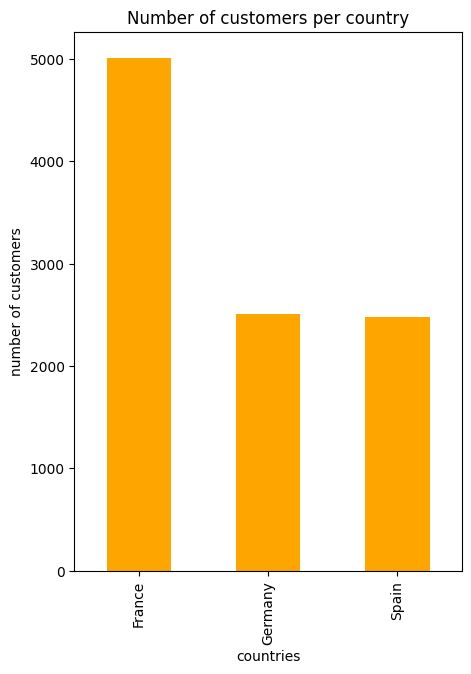

In [29]:
num_of_countries.plot(kind='bar',
                      x  = 'Geography',
                      y = 'count',
                      legend = False,
                      xlabel = 'countries',
                      ylabel='number of customers',
                      title = 'Number of customers per country',
                      color = 'orange',
                      figsize = (5, 7))

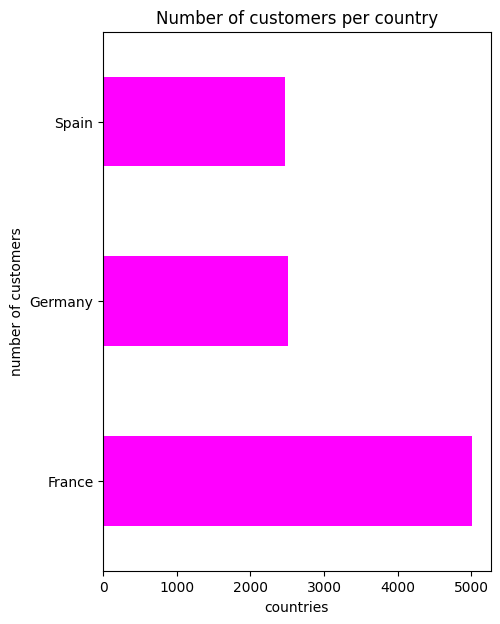

In [44]:
num_of_countries.plot(kind='barh',
                      x  = 'Geography',
                      y = 'count',
                      legend = False,
                      xlabel = 'countries',
                      ylabel='number of customers',
                      title = 'Number of customers per country',
                      color = 'magenta',
                      figsize = (5, 7));

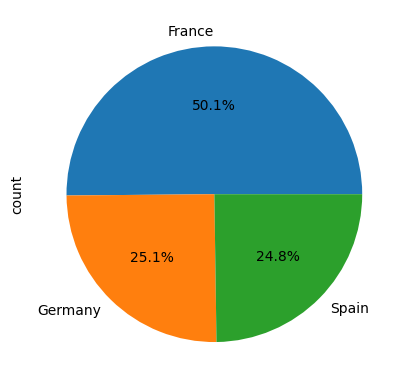

In [46]:
# @title Pie Charts
clean_cust_df['Geography'].value_counts()
clean_cust_df['Geography'].value_counts().plot(kind = 'pie',
                                             autopct = '%1.1f%%');
                                              #'%d%%'

In [49]:
num_of_countries

,Geography,count
0,France,5014
1,Germany,2509
2,Spain,2477


[Text(0, 0, '5,014'), Text(0, 0, '2,509'), Text(0, 0, '2,477')]

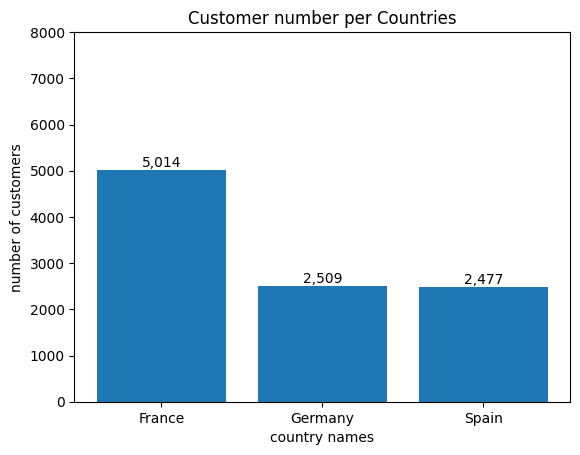

In [51]:
fig, ax = plt.subplots()
bar_container = ax.bar(num_of_countries['Geography'], num_of_countries['count'])
ax.set(ylabel='number of customers',
       xlabel = 'country names',
       title='Customer number per Countries', ylim=(0, 8000))
ax.bar_label(bar_container, fmt='{:,.0f}')

In [75]:
age_counts = clean_cust_df['Age_Bins'].value_counts().reset_index()

[Text(0.5, 1.0, 'Customer number per Age Bins')]

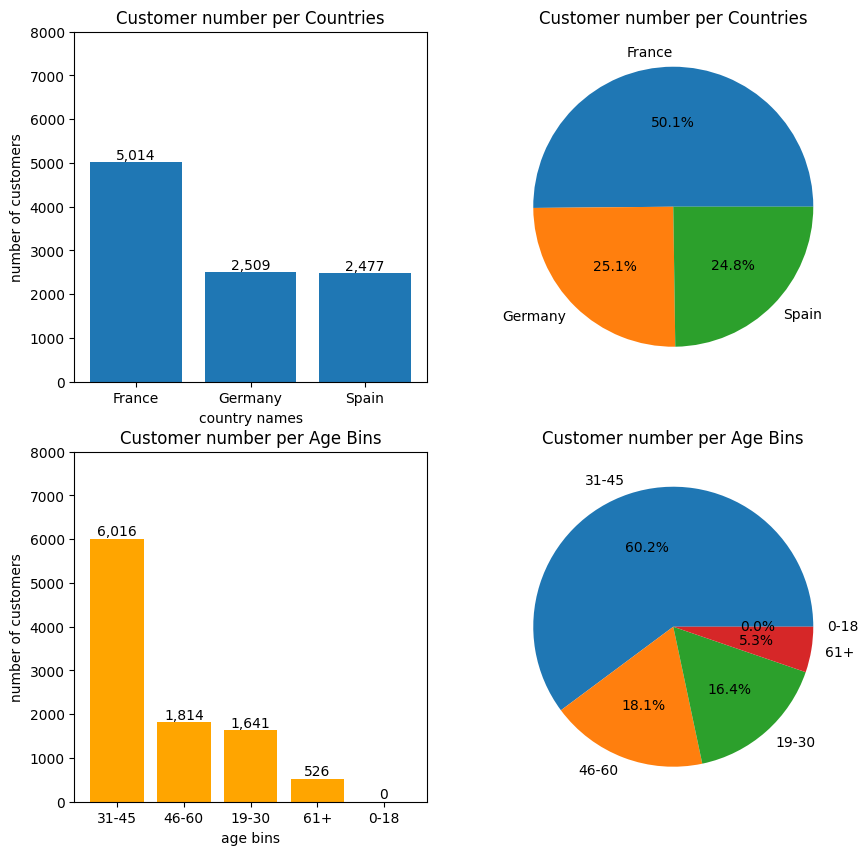

In [84]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
bar_container = ax[0,0].bar(num_of_countries['Geography'],
                          num_of_countries['count'])
ax[0,0].set(ylabel='number of customers',
       xlabel = 'country names',
       title='Customer number per Countries', ylim=(0, 8000))
ax[0,0].bar_label(bar_container, fmt='{:,.0f}')


pie_container = ax[0,1].pie(num_of_countries['count'],
                          labels = num_of_countries['Geography'],
                          autopct = '%1.1f%%')
ax[0,1].set(title='Customer number per Countries')


bar_container2 = ax[1,0].bar(age_counts['Age_Bins'],
                          age_counts['count'],
                          color = 'orange')
ax[1,0].set(ylabel='number of customers',
       xlabel = 'age bins',
       title='Customer number per Age Bins', ylim=(0, 8000))
ax[1,0].bar_label(bar_container2, fmt='{:,.0f}')


pie_container2 = ax[1,1].pie(age_counts['count'],
                          labels = age_counts['Age_Bins'],
                          autopct = '%1.1f%%')
ax[1,1].set(title='Customer number per Age Bins')


<Axes: >

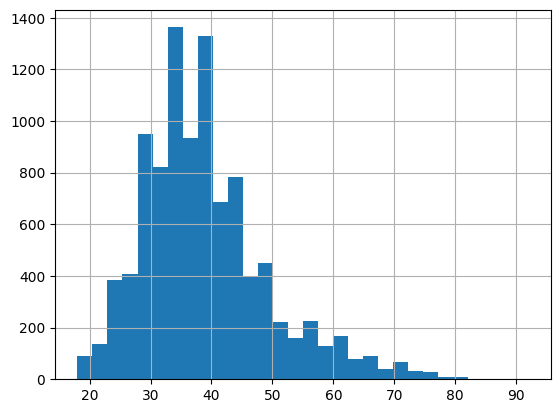

In [55]:
# @title Histogram

# histogram for age variable
cust_df['Age'].hist(bins=30)

<Axes: ylabel='Density'>

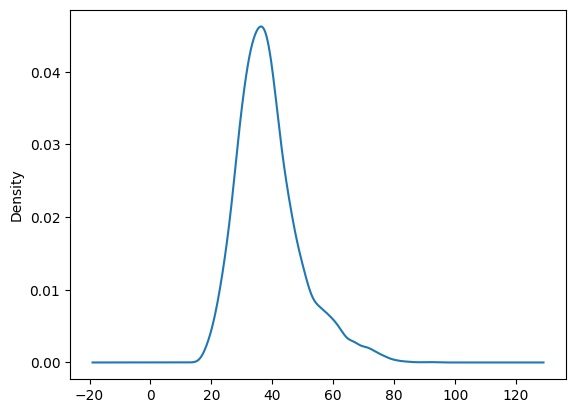

In [57]:
cust_df['Age'].plot(kind='density')

<Axes: ylabel='Frequency'>

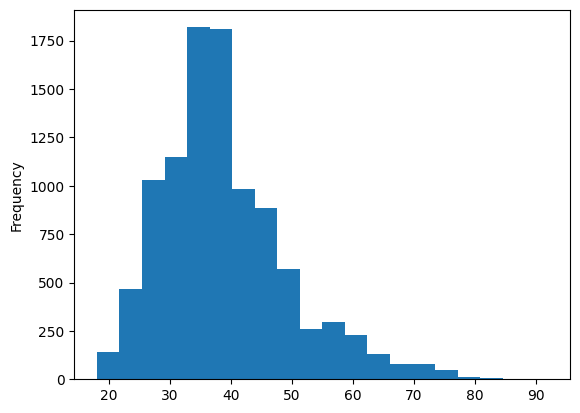

In [53]:
cust_df['Age'].plot.hist(bins=20)

In [ ]:
cust_df_mod['Age'].plot(kind = 'hist', bins = 10)

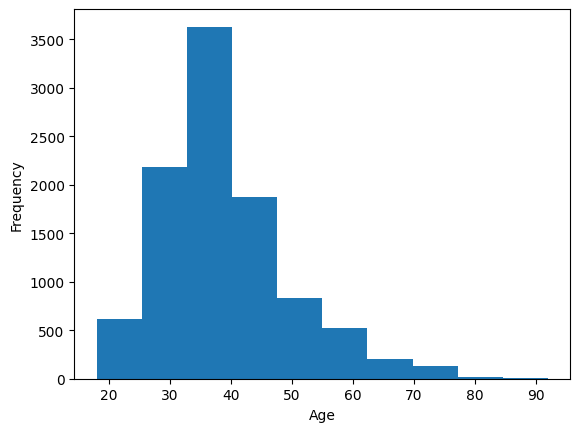

In [60]:
plt.hist(cust_df['Age'], bins = 10)
x = plt.xlabel('Age')
y = plt.ylabel('Frequency')
plt.show()

### Bivariate analysis

<Axes: xlabel='Age', ylabel='CreditScore'>

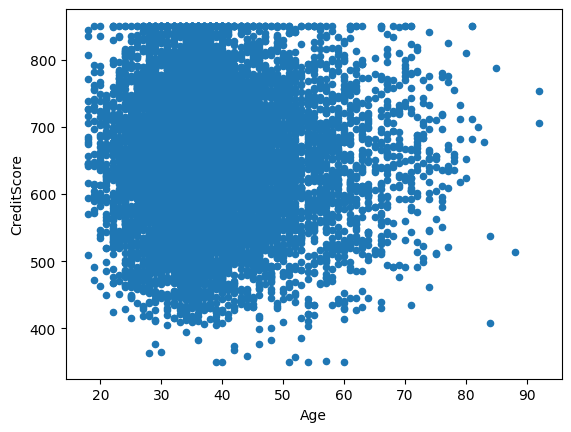

In [ ]:
cust_df.plot.scatter(x = 'Age', y = 'CreditScore')

<Axes: xlabel='Age', ylabel='CreditScore'>

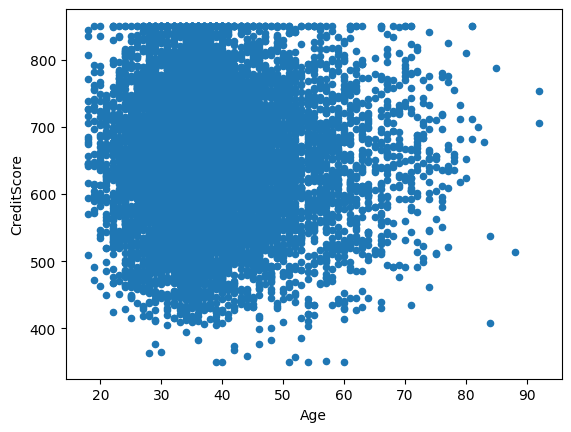

In [ ]:
cust_df.plot(kind = 'scatter',
             x = 'Age',
             y = 'CreditScore')

In [85]:
import plotly.express as px

In [86]:
px.scatter(clean_cust_df,
           x='Age',
           y='CreditScore')

In [87]:
# x and y given as DataFrame columns
import plotly.express as px
df = px.data.iris() # iris is a pandas DataFrame
fig = px.scatter(df, x="sepal_width", y="sepal_length")
fig.show()

In [88]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter(df, x="sepal_width", y="sepal_length", color="species",
                 size='petal_length', hover_data=['petal_width'])
fig.show()

In [95]:
fig = px.scatter(clean_cust_df, x="Age", y="CreditScore", color="Gender",
                 size='Tenure')
fig.show()

In [100]:
df = sns.load_dataset('titanic')
display(df.head())
fig = px.scatter(df, x="age", y="survived", color="class",
                 size='fare')
fig.show()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [89]:
clean_cust_df

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary [in Euros],Age_Bins
0,15634602,619,France,Female,42.0,2,101348.88,31-45
1,15647311,608,Spain,Female,41.0,1,112542.58,31-45
2,15619304,502,France,Female,42.0,8,113931.57,31-45
3,15701354,699,France,Female,39.0,1,93826.63,31-45
4,15737888,850,Spain,Female,43.0,2,79084.10,31-45
...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39.0,5,96270.64,31-45
9996,15569892,516,France,Male,35.0,10,101699.77,31-45
9997,15584532,709,France,Female,36.0,7,42085.58,31-45
9998,15682355,772,Germany,Male,42.0,3,92888.52,31-45
